In [1]:
import pandas as pd
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Problema
În acest proiect am abordat problema detectării review-urilor false (fake reviews) folosind tehnici de procesare a limbajului natural (NLP) și machine learning. Problema este formulată ca o problemă de clasificare binară, în care modelul trebuie să determine dacă un review este real sau fake pe baza textului acestuia.

#Contextul de utilizare
Acest tip de sistem ar putea fi utilizat de o platformă de e-commerce sau de recenzii online care dorește să identifice și să filtreze review-urile false. Review-urile fake pot influența percepția utilizatorilor asupra unui produs și pot afecta deciziile de cumpărare.
#Impactul asteptat
Modelul dezvoltat în acest proiect poate ajuta platformele online să identifice automat review-urile suspecte sau false, contribuind la creșterea încrederii utilizatorilor în sistemele de recenzii.

În practică, acest model ar putea fi integrat într-un sistem care analizează review-urile noi și marchează cele care au o probabilitate mare de a fi false, astfel încât acestea să fie verificate sau filtrate.

In [2]:
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/fake_reviews.csv")
print(df.head(), df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB
             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information

In [3]:
df_books = df[df["category"] == "Books_5"].copy()

print(df_books["label"].unique())
print(df_books["label"].value_counts())

['CG' 'OR']
label
CG    2185
OR    2185
Name: count, dtype: int64


In [4]:
df_books["label_num"] = df_books["label"].map({"CG": 1, "OR": 0})
print(df_books.head(), df_books.info(), df_books.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 4370 entries, 28420 to 32789
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   category   4370 non-null   object 
 1   rating     4370 non-null   float64
 2   label      4370 non-null   object 
 3   text_      4370 non-null   object 
 4   label_num  4370 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 204.8+ KB
      category  rating label  \
28420  Books_5     5.0    CG   
28421  Books_5     5.0    CG   
28422  Books_5     5.0    CG   
28423  Books_5     5.0    CG   
28424  Books_5     5.0    CG   

                                                   text_  label_num  
28420  I'm hooked on this writer and will be reading ...          1  
28421  Good book and exactly as described. The charac...          1  
28422  Fitting that the ultimate survivor of an epide...          1  
28423  Absolutely loved every word!  We have the book...          1  
28424  

In [5]:
df_books.isnull().sum()

,0
category,0
rating,0
label,0
text_,0
label_num,0


Graficul arata ca numarul de review-uri fake (CG) si review-uri reale (OR) este aproximativ echilibrat in dataset. Acest lucru este benefic pentru antrenarea modelului, deoarece modelele de clasificare functioneaza mai bine atunci cand clasele sunt distribuite relativ uniform

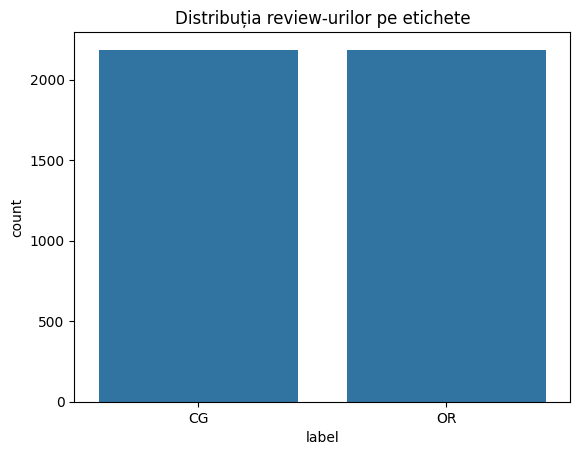

In [6]:
sns.countplot(data=df_books, x="label")
plt.title("Distribuția review-urilor pe etichete")
plt.show()

Distribuția lungimii review-urilor arata ca majoritatea review-urilor sunt relativ scurte, iar frecventa acestora scade pe masura ce lungimea textului creste. Exista totusi si cateva review-uri mult mai lungi, care pot reprezenta opinii mai detaliate ale utilizatorilor

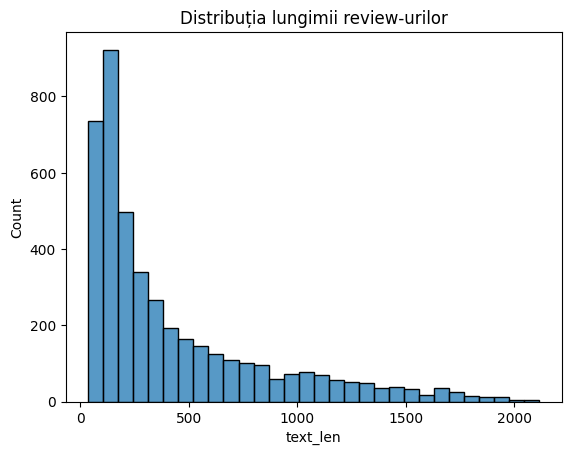

In [7]:
df_books["text_len"] = df_books["text_"].astype(str).apply(len)

sns.histplot(data=df_books, x="text_len", bins=30)
plt.title("Distribuția lungimii review-urilor")
plt.show()

Word cloud evidentiaza cele mai frecvente cuvinte din review-uri. Se observa in principal cuvinte precum book, read, story, character și author

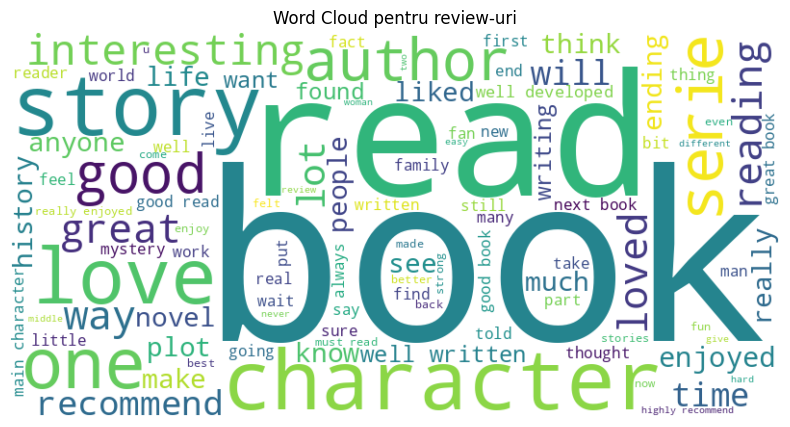

In [8]:
text = " ".join(df_books["text_"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud pentru review-uri")
plt.show()

# **Preprocesarea Datelor**

Am curatat textul review-urilor prin conversia tuturor caracterelor la litere mici si eliminarea punctuatiei si caracterelor speciale.

Acest pas este necesar pentru a reduce variațiile inutile din text. De exemplu, cuvintele "Book" și "book" ar trebui tratate ca acelasi cuvant. Eliminarea punctuatiei ajuta modelul sa se concentreze pe conținutul semantic al review-urilor.

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_books["clean_text"] = df_books["text_"].apply(clean_text)

Am separat datele în doua componente principale:
X contine textul review-urilor curatate (clean_text), iar y conține eticheta fiecarui review (label_num), care indica daca review-ul este fake sau real. Apoi am împartit datasetul în doua subseturi: training set și test set, folosind functia train_test_split.

Impartirea datelor este necesara pentru a putea evalua performanta modelului pe date pe care nu le-a vazut in timpul antrenarii.
Training set-ul este folosit pentru antrenarea modelului, iar test set-ul este utilizat pentru a verifica cat de bine generalizeaza modelul pe date noi.

In [10]:
X = df_books["clean_text"]
y = df_books["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Am folosit metoda TF-IDF (Term Frequency – Inverse Document Frequency) pentru
a transforma textul review-urilor in vectori numerici. Aceasta metoda reprezinta fiecare review ca un vector de valori numerice bazate pe frecventa si importanta cuvintelor din dataset. In acest mod, textul poate fi folosit ca input pentru modelele de machine learning.


Modelele de machine learning nu pot lucra direct cu text. Prin urmare, textul trebuie convertit intr-o forma numerica. TF-IDF este o metoda eficienta care evidentiaza cuvintele importante dintr-un document si reduce importanta cuvintelor foarte comune.

max_features = 5000 -> am limitat vocabularul la cele mai importante 5000 de cuvinte din dataset pentru a reduce dimensiunea datelor si a imbunatati performanta modelului

stop_words = "english" -> am eliminat cuvinte foarte frecvente precum "the", "and", "is", deoarece acestea nu contribuie semnificativ la identificarea review-urilor fake

fit_transform(X_train) -> pe setul de antrenare, modelul invata vocabularul si calculeaza valorile TF-IDF

transform(X_test) -> pe setul de test, folosim acelasi vocabular invatat din training pentru a transforma datele in vectori numerici

In [11]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Am antrenat un model Multinomial Naive Bayes pentru clasificarea review-urilor. Acest model este frecvent utilizat in procesarea limbajului natural deoarece functioneaza eficient pentru date text reprezentate prin frecventa cuvintelor, cum este cazul vectorilor TF-IDF

Multinomial Naive Bayes este un algoritm probabilistic bazat pe teorema lui Bayes. Modelul presupune independenta cuvintelor si calculeaza probabilitatea ca un review să apartina unei anumite clase

model_nb.fit(X_train_tfidf, y_train) -> in aceasta etapa modelul este antrenat folosind setul de training. Modelul invata distributia cuvintelor pentru fiecare clasa si estimeaza probabilitatea ca un review să fie fake sau real

model_nb.predict(X_test_tfidf) -> dupa antrenare, modelul prezice etichetele review-urilor din setul de test. Aceste predictii sunt utilizate ulterior pentru evaluarea performantei modelului

In [12]:
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)
y_pred_nb = model_nb.predict(X_test_tfidf)

Accuracy - aceasta metrica masoara proportia de predictii corecte realizate de model pe setul de test

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.8112128146453089
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       437
           1       0.76      0.92      0.83       437

    accuracy                           0.81       874
   macro avg       0.83      0.81      0.81       874
weighted avg       0.83      0.81      0.81       874



Am folosit functia classification_report din biblioteca scikit-learn pentru a obtine un raport detaliat al performantei modelului de clasificare. Acest raport include mai multe metrici importante precum precision, recall, F1-score și support pentru fiecare clasă

Precision arata cat de corecte sunt predictiile modelului pentru o anumita clasa

Recall arată cat de bine reuseste modelul sa gaseasca toate exemplele reale dintr-o clasa

F1-Score este media dintre precision si recall si ofera o masura echilibrata a performantei modelului

In [15]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79       437
           1       0.76      0.92      0.83       437

    accuracy                           0.81       874
   macro avg       0.83      0.81      0.81       874
weighted avg       0.83      0.81      0.81       874



Am calculat matricea de confuzie pentru a analiza performanta modelului Multinomial Naive Bayes. Aceasta arata cate exemple au fost clasificate corect si cate au fost clasificate gresit

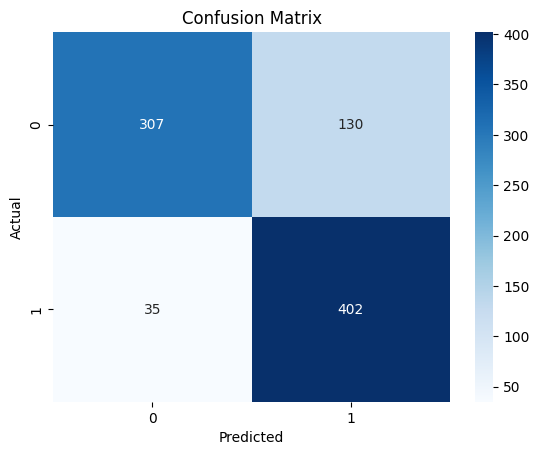

In [17]:
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()